In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath('../code'))

from methods_time_integrals import find_Rnod, integrate

In [8]:
# Define the data path where datasets are stored
datapath = "../data/"

# Define the drag coefficient
dt = 60*60*24

H = 3114
rho = 1025
Cd = 0.003

# Define the filenames for the datasets 
A4_file = "A4/A4_lofoten_h_50km_timeseries.nc" 
L800_file = "lofoten800/lofoten800_lofoten_h_50km_timeseries.nc" 

# Load the datasets using xarray
ts_A4 = xr.open_dataset(datapath + A4_file)
ts_L800 = xr.open_dataset(datapath + L800_file).sel(ocean_time=slice("01.01.1997", None))

# Adjusting surface stress
ts_A4["taucirc_area"] = ts_A4.taucirc_area/(H*rho)

#ts_L800["taucirc_area"] = ts_L800.taucirc_area/(H*rho)

# Combining the two vorticity terms
#ts_L800["zflux_area"] = ts_L800.zbarflux_area + ts_L800.znodflux_area


# Interpolating missing values TODO : fill in data gaps
ts_L800["ucirc_area"] = ts_L800["ucirc_area"].interpolate_na(dim="ocean_time", method="linear")
ts_L800["ucirc_area"] = ts_L800["ucirc_area"].interpolate_na(dim="ocean_time", method="linear")
#ts_L800["ub2circ"] = ts_L800["ub2circ"].interpolate_na(dim="ocean_time", method="linear")
#
sns.set_theme("notebook")

In [12]:
ts_L800

ds_out = ts_L800.drop_vars(["Vflux_area", "Vflux_line", "fflux_area", "fflux_line"])
for var in ["zbarflux_area", "zbarflux_line", "znodflux_area", "znodflux_line"]:
    ds_out[var] = -ds_out[var]

ds_out.to_netcdf("/home/alsjur/PhD/Kode/Vorticity-Driven-Circulation/Zenodo/data/lofoten800_lofoten_h_50km_timeseries.nc")

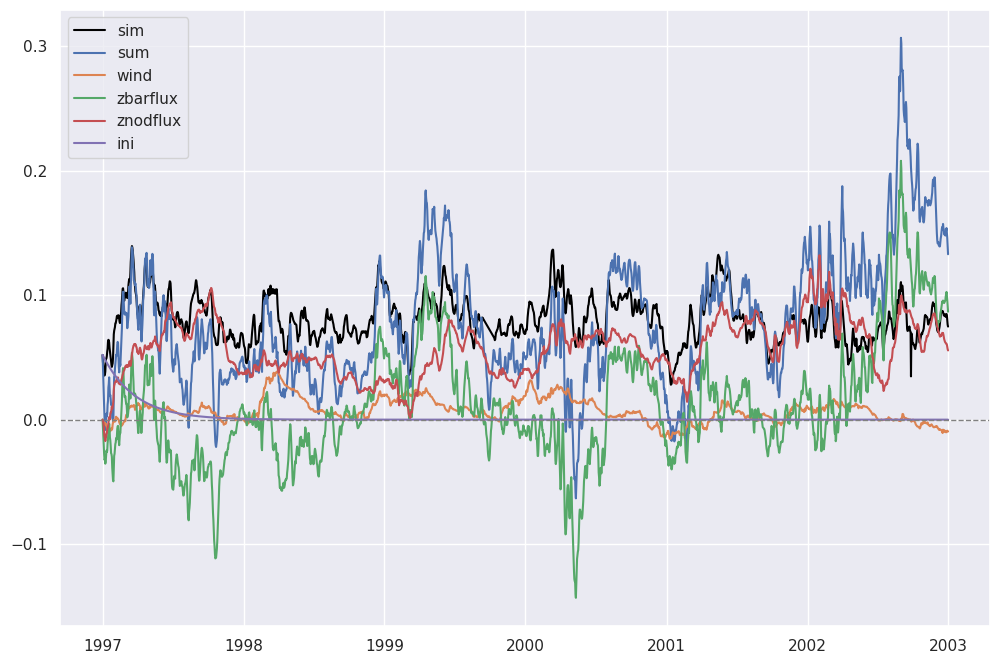

In [41]:
L = ts_L800.L_line
t = ts_L800.ocean_time

C = ts_L800.ucirc_area/L
C0 = C.isel(ocean_time=0)
f_wind = ts_L800.taucirc_area.values/L
f_zbarflux = ts_L800.zbarflux_area.values/L
f_znodflux = ts_L800.znodflux_area.values/L
f_fflux = ts_L800.fflux_area.values/L
f_ini = np.zeros_like(f_wind)

R = np.nanmean(find_Rnod(ts_L800, Cd))

C_ini = integrate(f_ini, dt, C0, friction="linear", R=R)
C_wind = integrate(f_wind, dt, 0, friction="linear", R=R)
C_zbarflux = integrate(f_zbarflux, dt, 0, friction="linear", R=R)
C_znodflux = integrate(f_znodflux, dt, 0, friction="linear", R=R)
C_fflux = integrate(f_fflux, dt, 0, friction="linear", R=R)


fig, ax = plt.subplots(figsize=(12,8))

ax.plot(t, C, color="black", label = "sim")
ax.plot(t, C_ini+C_wind+C_zbarflux+C_znodflux, label="sum")
#ax.plot(t, C_fflux, label="fflux")
ax.plot(t, C_wind, label="wind")
ax.plot(t, C_zbarflux, label="zbarflux")
ax.plot(t, C_znodflux, label="znodflux")
ax.plot(t, C_ini, label="ini")
ax.axhline(0, lw=1,  ls="--", color="gray")

ax.legend()

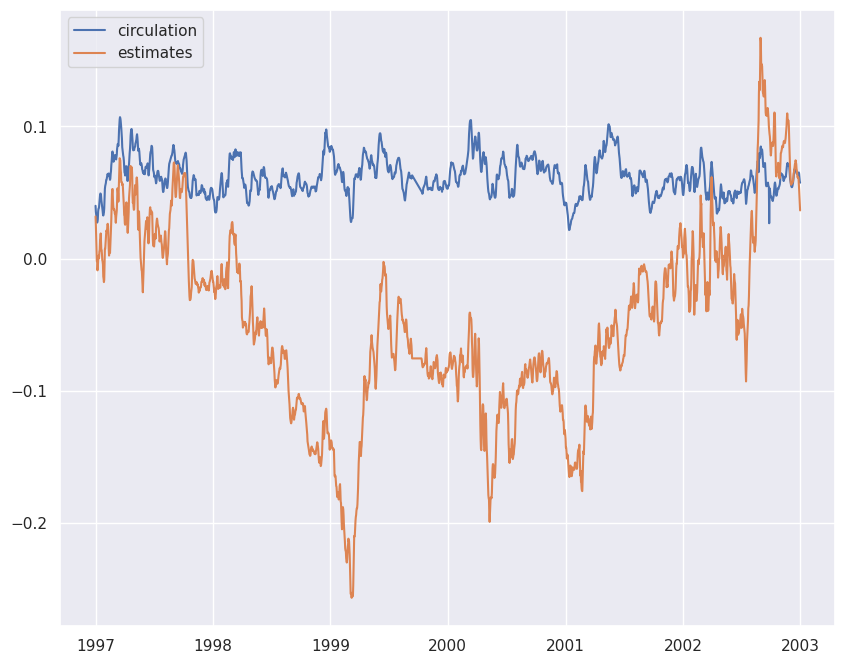

In [22]:
L_L800 = ts_L800.L_area
C_L800 = ts_L800.ucirc_area/L_L800
C0_L800 = C_L800.isel(ocean_time=0)



dCest_L800 = (( 
    + ts_L800.taucirc_area 
    + ts_L800.zflux_area 
    - ts_L800.fflux_area
    - Cd*ts_L800.ub2circ_area/H
    )/L_L800)

dC_L800 = C_L800.differentiate("ocean_time", datetime_unit = "s")

Cest_L800 = (dCest_L800*dt).cumsum("ocean_time")+C0_L800


fig, ax = plt.subplots(figsize=(10,8))

t = ts_L800.ocean_time
ax.plot(t, C_L800, label="circulation")
ax.plot(t, Cest_L800, label="estimates")

ax.legend()

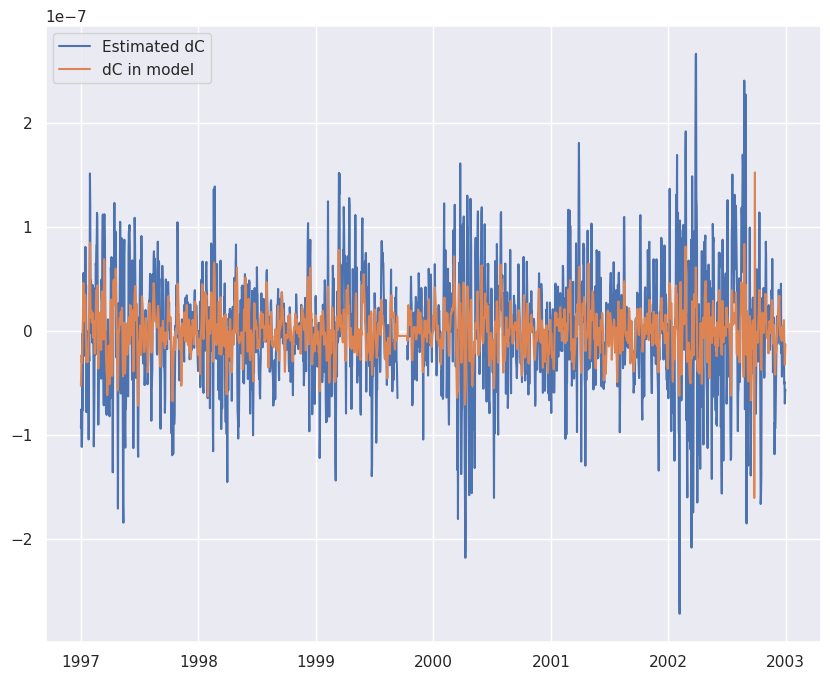

In [23]:
fig, ax = plt.subplots(figsize=(10,8))

t = ts_L800.ocean_time
ax.plot(t, dCest_L800, label="Estimated dC")
ax.plot(t, dC_L800, label="dC in model")

ax.legend()

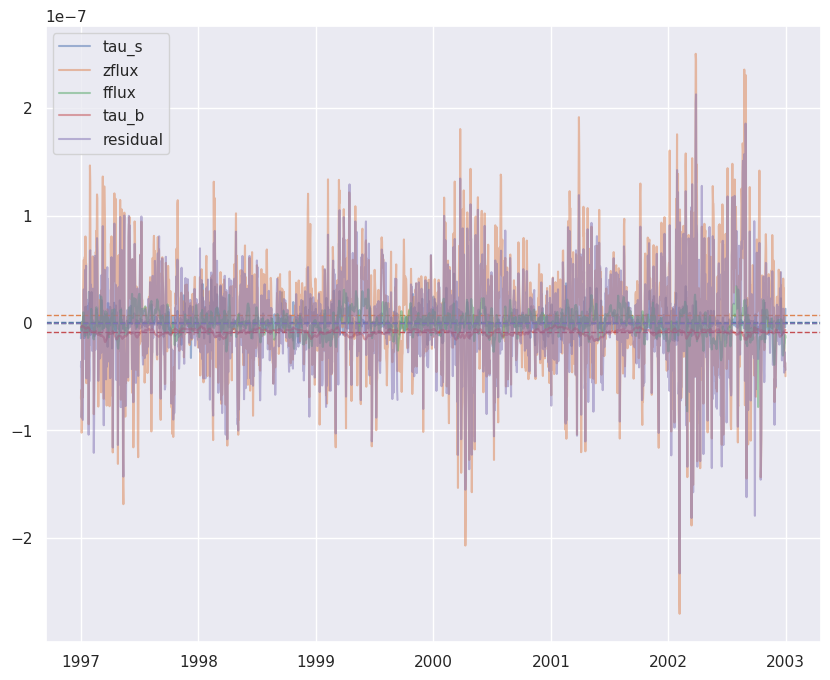

In [24]:
fig, ax = plt.subplots(figsize=(10,8))

dt_components = dict(
    tau_s=ts_L800.taucirc_area/L_L800, 
    zflux=+ ts_L800.zflux_area/L_L800, 
    fflux=- ts_L800.fflux_area/L_L800,
    tau_b=-Cd*ts_L800.ub2circ_area/L_L800/H,
    residual = dCest_L800-dC_L800
    
)



for label, dt in dt_components.items():
        # Plot the time series
    line, = ax.plot(t, dt, alpha=0.5, label=label)
    
    # Calculate and plot the time mean
    time_mean = dt.mean()
    ax.axhline(time_mean, color=line.get_color(), linestyle='--', linewidth=1)



ax.legend()
#ax.set_ylim(-1e-8, 1e-8)

tau_s 7.397415992829906e-10
zflux 7.764440927187396e-09
fflux -1.0695300328812541e-10
tau_b -8.588041203294085e-09
residual -1.6081519669252472e-10


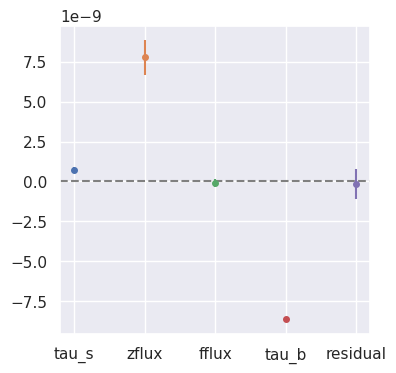

In [25]:
fig, ax = plt.subplots(figsize=(4,4))

i = 0
pos = []
labels = []
for label, dt in dt_components.items():
    dt_mean = dt.mean()
    dt_std = dt.std()
    conf = dt_std/np.sqrt(len(dt))

    ax.errorbar(i, dt_mean, yerr=conf, marker='o', markersize=4,label=label)
    pos.append(i)
    labels.append(label)
    print(label, dt_mean.values)
    i += 1

ax.axhline(0, color="gray", ls="--")
ax.set_xticks(pos, labels)

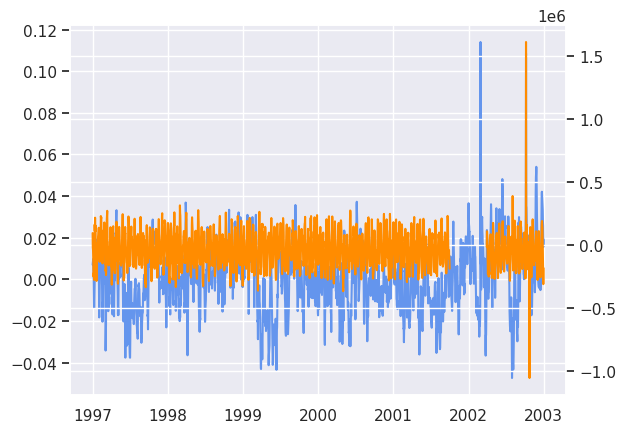

In [26]:
fflux = ts_L800.fflux_area
Vflux = ts_L800.Vflux_area
t = ts_L800.ocean_time

fig, ax = plt.subplots()

#ax.scatter(fflux, Vflux)

ax2 = ax.twinx()

ax.plot(t, fflux, color="cornflowerblue")
ax2.plot(t, Vflux, color="darkorange")


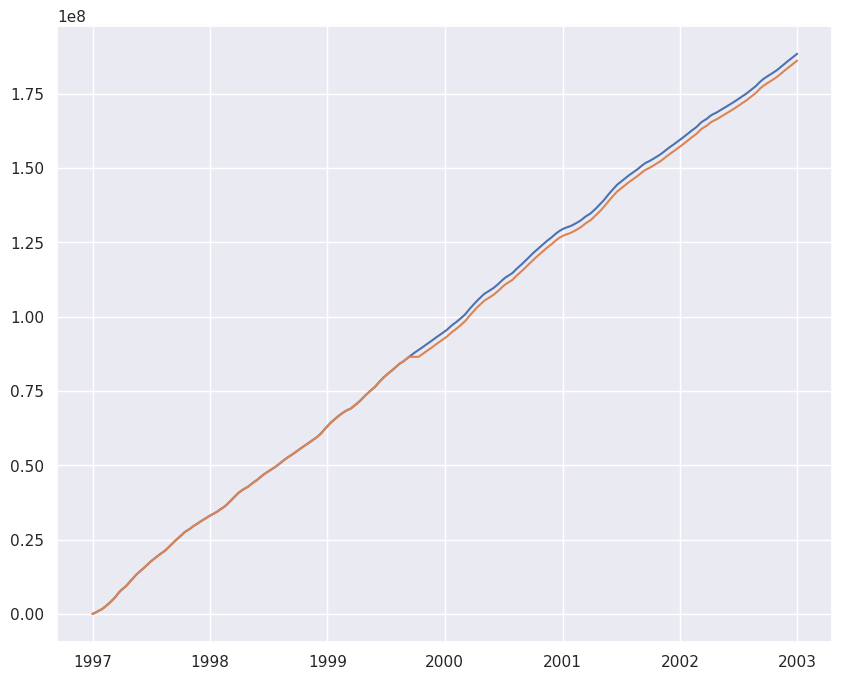

In [27]:
u_area = ts_L800.ucirc_area
u_line = ts_L800.ucirc_line

fig, ax = plt.subplots(figsize=(10,8))

ax.plot(t, np.cumsum(u_area))
ax.plot(t, np.cumsum(u_line))

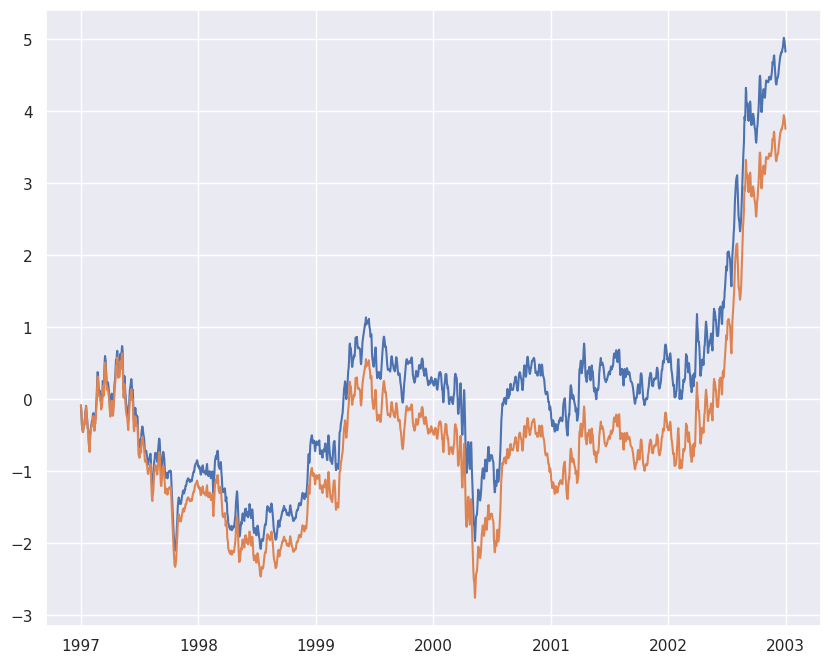

In [28]:
z_area = ts_L800.zbarflux_area
z_line = ts_L800.zbarflux_line

fig, ax = plt.subplots(figsize=(10,8))

#ax.plot(t, z_area)
#ax.plot(t, z_line)

ax.plot(t, np.cumsum(z_area))
ax.plot(t, np.cumsum(z_line))

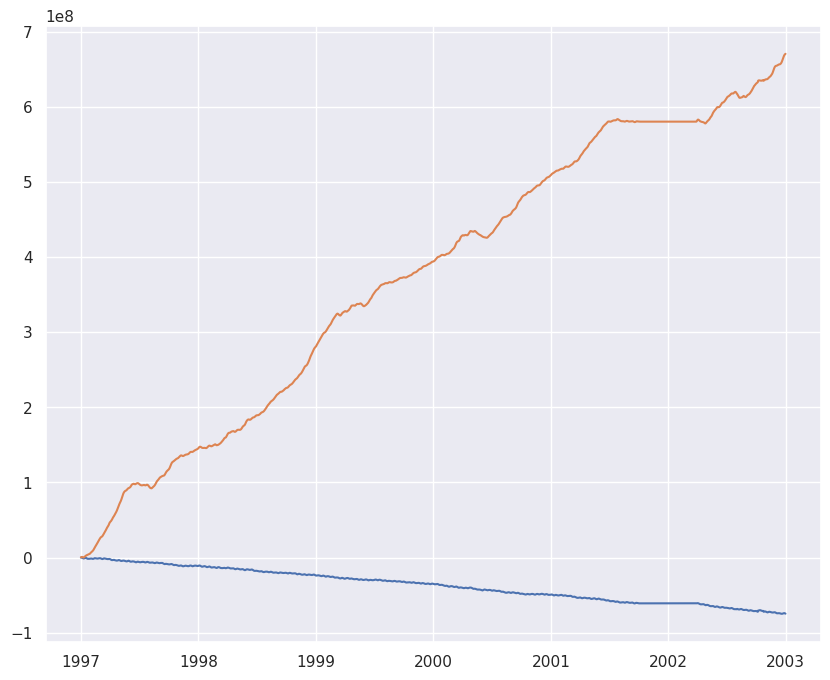

In [29]:
V_area = ts_L800.Vflux_area
V_line = ts_L800.Vflux_line

fig, ax = plt.subplots(figsize=(10,8))

#ax.plot(t, z_area)
#ax.plot(t, z_line)

ax.plot(t, np.cumsum(V_area))
ax.plot(t, np.cumsum(V_line))

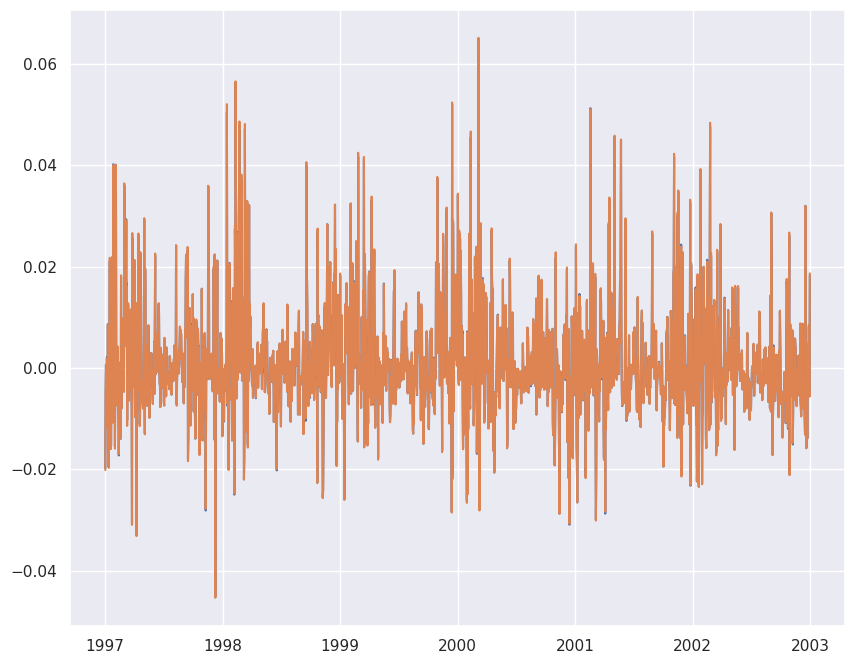

In [30]:
tau_area = ts_L800.taucirc_area
tau_line = ts_L800.taucirc_line

fig, ax = plt.subplots(figsize=(10,8))

ax.plot(t, tau_area)
ax.plot(t, tau_line)

# ax.plot(t, np.cumsum(tau_area))
# ax.plot(t, np.cumsum(tau_line))

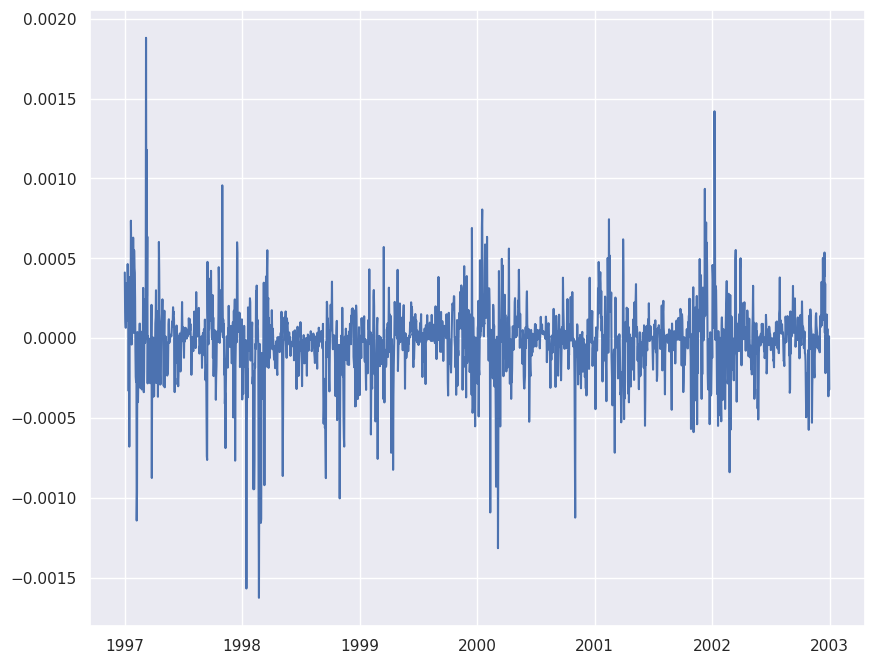

In [31]:
diff = tau_area - tau_line


fig, ax = plt.subplots(figsize=(10,8))
ax.plot(t, diff)

In [32]:
(np.abs(diff)/tau_area).mean("ocean_time")

<xarray.DataArray ()>
array(-0.04520096)
Coordinates:
    L        float64 1.388e+06

In [3]:
ts = xr.open_dataset("/home/alsjur/PhD/Kode/Vorticity-Driven-Circulation/Zenodo/lofoten800_time_integrals.nc")

In [4]:
ts

<xarray.Dataset>
Dimensions:     (ocean_time: 2191, term: 4)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 1997-01-01 1997-01-02 ... 2002-12-31
  * term        (term) object 'initial state' ... 'baroclinic vorticity'
Data variables:
    C           (ocean_time) float64 ...
    estimates   (term, ocean_time) float64 ...
Attributes:
    r:        0.00042542700068493906
    L:        1065910.156265458

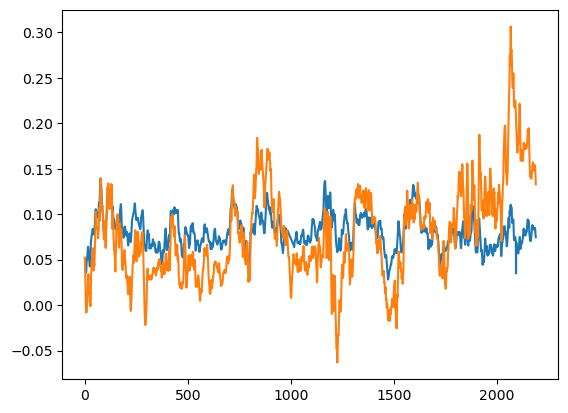

In [6]:
fig, ax = plt.subplots()


ax.plot(ts.C)
ax.plot(ts.estimates.sum("term"))